# 01 · Data Profiling & Quality

This notebook profiles the **pre-cleaned** benchmark dataset before analysis.
Cleaning (outlier removal + unit conversion) was already performed by
`notebooks/01_data_cleaning.ipynb`, which produced `results/results_clean_runs.csv`.

**Cleaning pipeline (upstream):**
- Outliers removed per **(language × benchmark)** group using the 1.5×IQR boxplot fence,
  applied to both CPU energy and execution time
- Units converted: µJ → J, µs → ms, µg → g, Bytes → MB, mW → W

**This notebook covers:**
- Column overview and descriptive statistics
- Missing value check
- Metric distributions
- Data coverage (languages × benchmarks)
- Per-language summary table

**Dataset:** 18 languages × 8 benchmarks, measured with the Green Metrics Tool (GMT).
**Priority metrics:** CPU Energy (J), Memory Energy (J), Execution Time (ms)

In [45]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # make the shared style module importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from itertools import combinations

import importlib
import plot_style as ps
importlib.reload(ps)   # pick up edits to plot_style.py without a kernel restart
ps.apply_style()

# Canonical constants — single source: plot_style.
COL_CPU_ENERGY, COL_MEM_ENERGY = ps.COL_CPU_ENERGY, ps.COL_MEM_ENERGY
COL_TIME                       = ps.COL_TIME
COL_CPU_CARBON, COL_MEM_CARBON = ps.COL_CPU_CARBON, ps.COL_MEM_CARBON
PARADIGM        = ps.PARADIGM
PARADIGM_COLORS = ps.PARADIGM_COLORS
PARADIGM_ORDER  = ps.PARADIGM_ORDER
MEANPROPS       = ps.MEANPROPS
ALPHA           = ps.ALPHA

OUTPUTS_DIR = Path('outputs'); OUTPUTS_DIR.mkdir(exist_ok=True)

# Single source of truth: per-run rows (df) + per-cell means with EDP (df_mean).
df      = ps.load_runs()
df_mean = ps.cell_means(df)

def lang_means(cols):
    """Per-language two-step mean (equal benchmark weight) for column(s) `cols`."""
    return ps.lang_means(df_mean, cols)

print(f"Runs: {df.shape} | Cell-means: {df_mean.shape} | "
      f"{df['language'].nunique()} languages \u00d7 {df['benchmark'].nunique()} benchmarks")
df_mean.head(3)

Runs: (1280, 17) | Cell-means: (144, 16) | 18 languages × 8 benchmarks


,language,benchmark,cpu_carbon_rapl_msr_component-package_0-g,cpu_energy_rapl_msr_component-package_0-j,disk_total_read_cgroup_container-container-mb,disk_total_write_cgroup_container-container-mb,embodied_carbon_share_machine-system-g,memory_carbon_rapl_msr_component-dram_0-g,memory_energy_rapl_msr_component-dram_0-j,network_carbon_formula_global-formula-g,network_energy_formula_global-formula-j,network_power_formula_global-formula-w,network_total_cgroup_container-container-mb,phase_time_syscall_system-system-ms,paradigm,EDP
0,C,binary-trees,0.002967,31.976886,0.192512,0.0,0.001753,0.000122,1.311170,0.000000e+00,0.000000,0.0,0.000000,1221.817400,AOT,40671.925300
1,C,fannkuch-redux,0.006453,69.556996,0.000000,0.0,0.003131,0.000063,0.682479,5.714286e-07,0.005702,0.0,0.000039,2182.097714,AOT,153269.397538
2,C,fasta,0.003574,38.523294,0.000000,0.0,0.002074,0.000081,0.870375,1.666667e-06,0.018067,0.0,0.000122,1445.462222,AOT,56942.061458


## 1. Column Overview

Extended `describe()` supplemented with median and IQR for the three priority columns.
Median is preferred over mean for right-skewed benchmark distributions.
All values are in human-readable units (J for energy, ms for time).

In [46]:
priority = [COL_CPU_ENERGY, COL_MEM_ENERGY, COL_TIME]
labels   = {COL_CPU_ENERGY: 'CPU Energy (J)',
            COL_MEM_ENERGY: 'Mem Energy (J)',
            COL_TIME:       'Time (ms)'}

stats_tbl = df[priority].describe().T
stats_tbl['median'] = df[priority].median()
stats_tbl['IQR']    = df[priority].quantile(0.75) - df[priority].quantile(0.25)
stats_tbl['skew']   = df[priority].skew()
stats_tbl.index     = [labels[c] for c in stats_tbl.index]
stats_tbl.round(4)

,count,mean,std,min,25%,50%,75%,max,median,IQR,skew
CPU Energy (J),1280.0,878.6371,1841.3281,8.6440,54.8354,181.9181,713.4515,12092.7936,181.9181,658.6161,3.7003
Mem Energy (J),1280.0,18.2485,67.5367,0.1484,1.2021,3.2025,15.1225,748.1624,3.2025,13.9203,9.7983
Time (ms),1280.0,33876.0128,70458.1506,393.0890,2533.4175,6642.6450,29441.9078,413484.9140,6642.6450,26908.4902,3.3506


## 2. Missing Values

Completeness check across all 16 columns. Benchmark datasets often contain zeros rather
than NaN for metrics that were not triggered (e.g. network bytes on a CPU-only task).

In [47]:
null_counts = df.isnull().sum()
if null_counts.sum() == 0:
    print("✓ No missing values — dataset is complete.")
else:
    print("Missing values detected:")
    print(null_counts[null_counts > 0])

# Check for zero-only columns (may indicate inactive metrics)
zero_frac = (df[priority] == 0).mean()
print("\nFraction of zeros in priority columns:")
for col, frac in zip(['CPU Energy', 'Mem Energy', 'Time'], zero_frac):
    print(f"  {col}: {frac:.1%}")

✓ No missing values — dataset is complete.

Fraction of zeros in priority columns:
  CPU Energy: 0.0%
  Mem Energy: 0.0%
  Time: 0.0%


## 3. Distributions

Histograms on a log₁₀ scale for the three priority metrics.
Benchmark data is typically right-skewed (a few languages/benchmarks dominate the upper tail).
Values are in J (energy) and ms (time).
A divergence of >20% between mean and median is flagged.

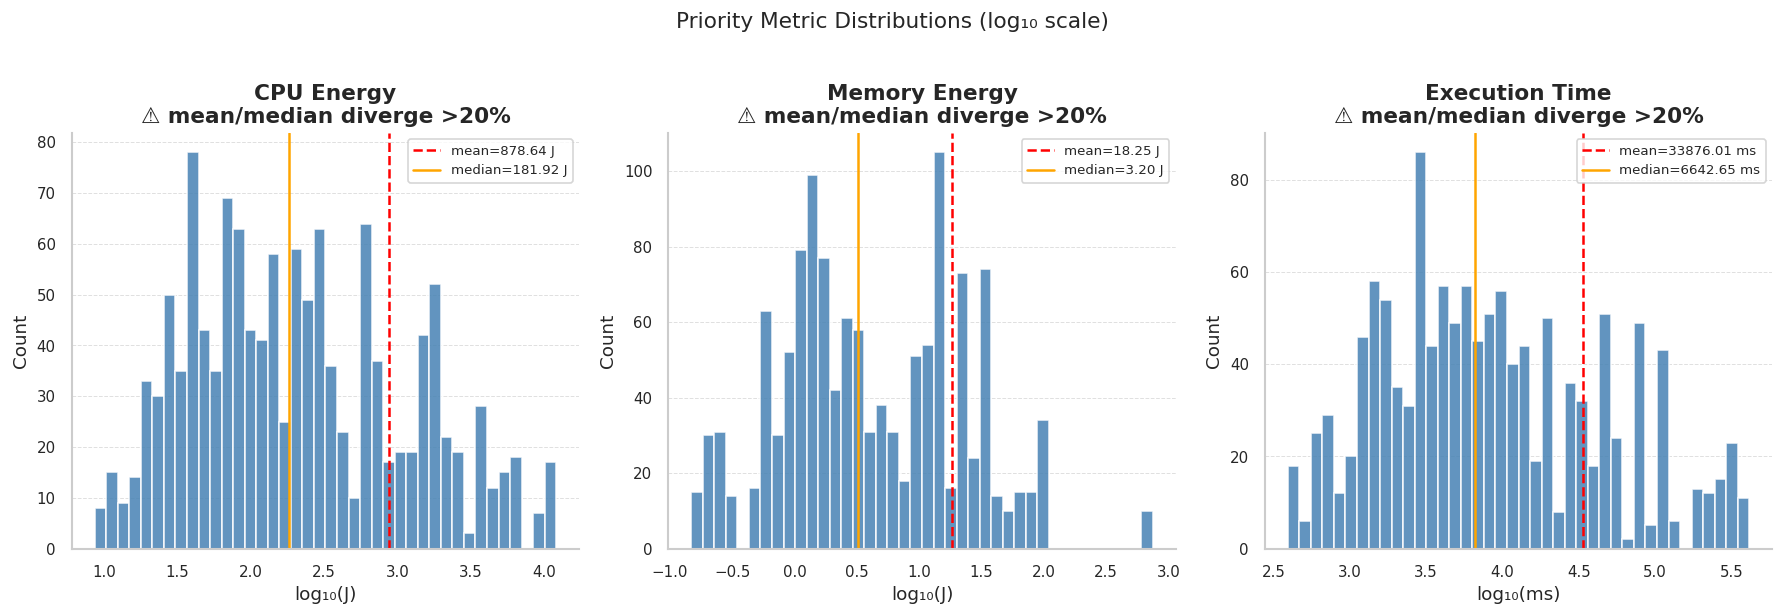

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metric_info = [
    ('CPU Energy', COL_CPU_ENERGY, 'J'),
    ('Memory Energy', COL_MEM_ENERGY, 'J'),
    ('Execution Time', COL_TIME, 'ms'),
]
for ax, (label, col, unit) in zip(axes, metric_info):
    vals = df[col][df[col] > 0]
    log_vals = np.log10(vals)
    ax.hist(log_vals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    mean_v, med_v = vals.mean(), vals.median()
    ax.axvline(np.log10(mean_v), color='red',    linestyle='--', label=f'mean={mean_v:.2f} {unit}')
    ax.axvline(np.log10(med_v),  color='orange', linestyle='-',  label=f'median={med_v:.2f} {unit}')
    ax.set_title(f'{label}')
    ax.set_xlabel(f'log₁₀({unit})')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    if abs(mean_v - med_v) / med_v > 0.20:
        ax.set_title(ax.get_title() + '\n⚠ mean/median diverge >20%')

fig.suptitle('Priority Metric Distributions (log₁₀ scale)', fontsize=13, y=1.02)
plt.tight_layout()
ps.save_fig(fig, '01_distributions')
plt.show()

> **Takeaway:** all three priority metrics are strongly right-skewed (mean ≫ median) — this is why rankings use means while the significance tests stay non-parametric.

## 4. Data Coverage

Heatmap showing the number of runs for each language × benchmark pair.
A uniform count across all cells indicates balanced coverage.

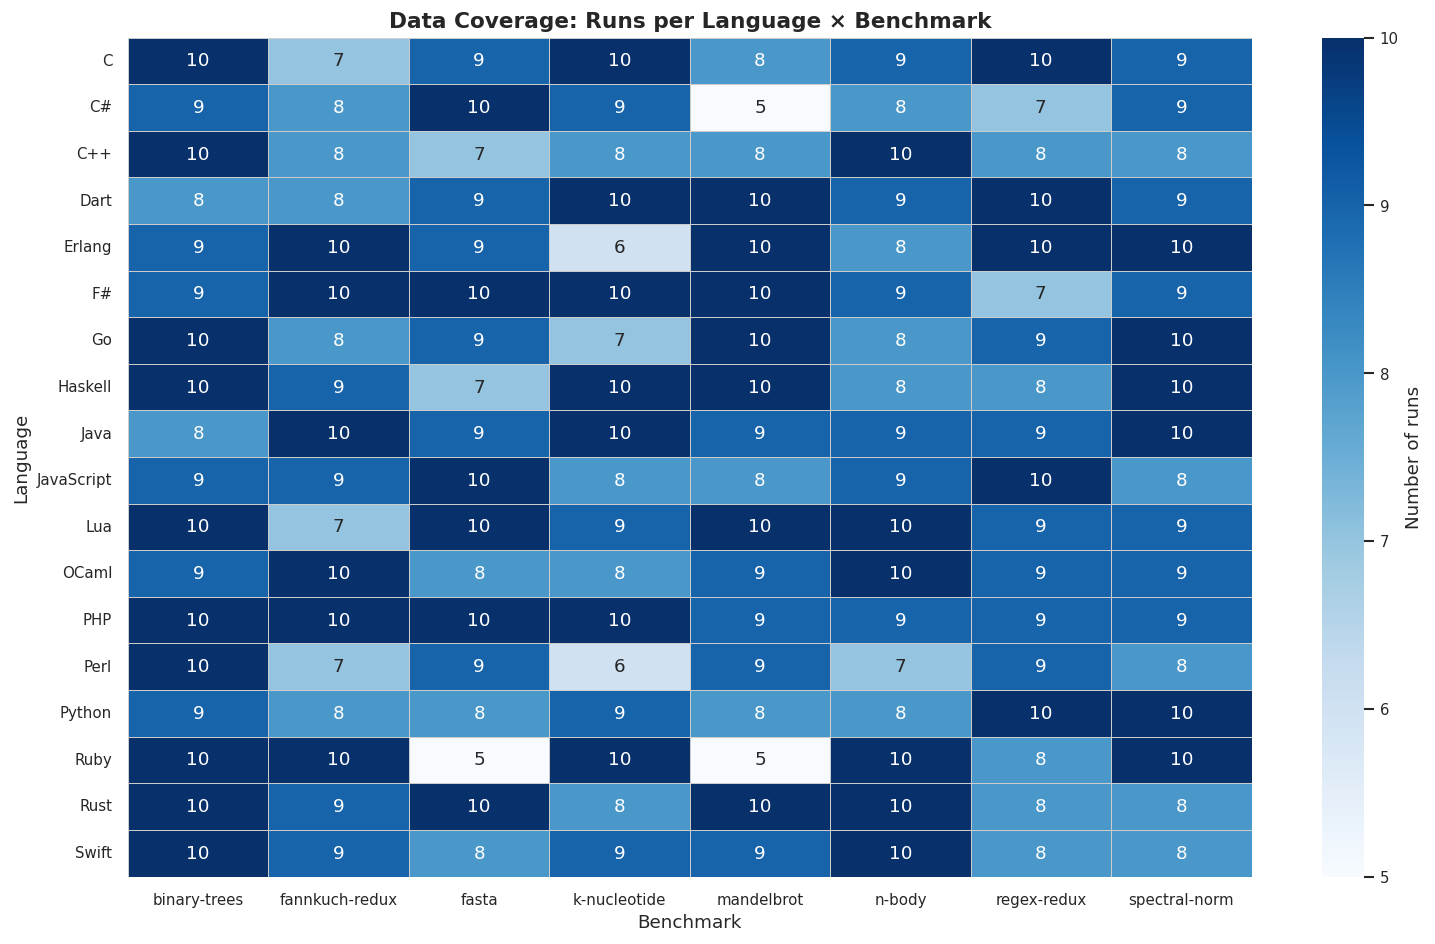

Min runs in any cell: 5
Max runs in any cell: 10
Mean runs per cell:   8.9


In [49]:
coverage = df.groupby(['language', 'benchmark']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(coverage, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.4, linecolor='#ccc',
            cbar_kws={'label': 'Number of runs'})
ax.set_title('Data Coverage: Runs per Language × Benchmark', fontsize=13)
ax.set_xlabel('Benchmark')
ax.set_ylabel('Language')
plt.tight_layout()
ps.save_fig(fig, '01_coverage_heatmap')
plt.show()
print(f"Min runs in any cell: {coverage.values.min()}")
print(f"Max runs in any cell: {coverage.values.max()}")
print(f"Mean runs per cell:   {coverage.values.mean():.1f}")

> **Takeaway:** every (language × benchmark) cell keeps 5–10 clean runs after outlier removal — coverage is complete and roughly balanced.

## 5. Summary Table

Per-language descriptive statistics for all three priority metrics in human-readable units.
Mean and median are both reported; large divergence signals skewness within a language.

In [50]:
summary_tbl = df.groupby('language').agg(
    paradigm      = ('paradigm', 'first'),
    runs          = ('run_id', 'count'),
    cpu_mean_J    = (COL_CPU_ENERGY, 'mean'),
    cpu_median_J  = (COL_CPU_ENERGY, 'median'),
    mem_mean_J    = (COL_MEM_ENERGY, 'mean'),
    mem_median_J  = (COL_MEM_ENERGY, 'median'),
    time_mean_ms   = (COL_TIME, 'mean'),
    time_median_ms = (COL_TIME, 'median'),
).round(4)

# Flag skew
for label, mc, mdc in [('CPU energy', 'cpu_mean_J', 'cpu_median_J'),
                        ('Mem energy', 'mem_mean_J', 'mem_median_J'),
                        ('Time',       'time_mean_ms','time_median_ms')]:
    skew_mask = (abs(summary_tbl[mc] - summary_tbl[mdc]) / summary_tbl[mdc]) > 0.20
    if skew_mask.any():
        print(f"⚠ {label} mean/median diverge >20% for: {list(summary_tbl.index[skew_mask])}")

summary_tbl.sort_values('runs', ascending=False)

⚠ CPU energy mean/median diverge >20% for: ['C', 'C++', 'Dart', 'F#', 'Go', 'Haskell', 'Java', 'JavaScript', 'Lua', 'PHP', 'Perl', 'Python', 'Ruby', 'Rust', 'Swift']
⚠ Mem energy mean/median diverge >20% for: ['C', 'C#', 'C++', 'Dart', 'Erlang', 'F#', 'Go', 'Haskell', 'Java', 'JavaScript', 'Lua', 'OCaml', 'PHP', 'Perl', 'Python', 'Ruby', 'Rust', 'Swift']
⚠ Time mean/median diverge >20% for: ['C', 'C#', 'C++', 'Dart', 'Erlang', 'F#', 'Go', 'Haskell', 'JavaScript', 'Lua', 'OCaml', 'PHP', 'Perl', 'Python', 'Rust', 'Swift']


,paradigm,runs,cpu_mean_J,cpu_median_J,mem_mean_J,mem_median_J,time_mean_ms,time_median_ms
language,,,,,,,,
PHP,JIT,76,1302.2958,625.7307,18.1373,15.0699,46677.2810,24683.0695
Lua,Interpreted,74,1752.1034,1398.1437,28.6774,23.5737,84599.1694,56597.7480
F#,JIT,74,116.0869,94.1421,3.1945,1.4065,4058.5678,3126.3345
Java,AOT,74,135.5141,109.5482,3.9344,1.9212,5080.9477,4332.9695
Rust,AOT,73,82.4563,34.5609,1.3708,0.8075,3068.7434,1823.9870
Dart,AOT,73,246.5623,159.4996,6.9844,2.0152,10693.1487,5650.6050
C,AOT,72,55.0583,38.6266,1.1425,0.8623,2099.3463,1530.2810
Erlang,JIT,72,1497.1888,1638.3233,114.8679,13.8254,88895.5730,43379.5010
Haskell,AOT,72,179.2048,54.4325,5.1110,2.5517,5879.4837,2182.2610


In [ ]:
# Per-language summary as a paste-ready table figure, ordered by run count (most → least).
summary_runs = summary_tbl.sort_values('runs', ascending=False)
summary_runs.to_csv(OUTPUTS_DIR / 'per_language_summary.csv')
print(f"Saved → {OUTPUTS_DIR / 'per_language_summary.csv'}")

# Display-formatted copy (strings) for the styled table figure (PNG + PDF).
disp = pd.DataFrame({
    'Paradigm':         summary_runs['paradigm'],
    'Runs':             summary_runs['runs'].astype(int).astype(str),
    'CPU mean (J)':     summary_runs['cpu_mean_J'].map(lambda v: f'{v:,.1f}'),
    'CPU median (J)':   summary_runs['cpu_median_J'].map(lambda v: f'{v:,.1f}'),
    'Mem mean (J)':     summary_runs['mem_mean_J'].map(lambda v: f'{v:,.2f}'),
    'Mem median (J)':   summary_runs['mem_median_J'].map(lambda v: f'{v:,.2f}'),
    'Time mean (ms)':   summary_runs['time_mean_ms'].map(lambda v: f'{v:,.0f}'),
    'Time median (ms)': summary_runs['time_median_ms'].map(lambda v: f'{v:,.0f}'),
}, index=summary_runs.index)
disp.index.name = 'Language'

ps.styled_table_fig(
    disp,
    'Per-Language Summary — mean & median per metric (ordered by run count)',
    '01_per_language_summary',
    row_paradigms=[PARADIGM[l] for l in disp.index],
)
disp